In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2
from IPython.display import Image, display

pd.reset_option('display.max_columns')

# Preparación de los datos

## Introducción

### Objetivos

- Comprender la importancia de una adecuada preparación de los datos.

- Identificar los principales desafíos al trabajar con datos.

- Conectar los pasos de Data-Cleaning y Standardization con la toma de decisiones.

### Breve repaso del ciclo de vida de un proyecto de análisis de datos:

1. Comprensión del problema de negocio

2. Recolección y comprensión de los datos

3. Limpieza y preparación

4. Análisis y modelado

5. Comunicación de resultados

### Contexto:

- La calidad de los datos tienen un gran impacto a la hora de realizar un análisis descriptivo y obtener un buen desempeño del modelo.

- Garbage in, garbage out.

- Para llegar a buenos resultados se hace necesario corregir inconsistencias, errores e información irrelevante.

### ¿Qué es data processing?

- Procesar la data inicial para análisis posteriores así como tareas de modelado.

- Paso preliminar al analisis de datos.

- La idea es procesar la data en un formato que pueda ser usado tareas como:
  * Analisis de datos
  * Machine Learning
  * Sciencia de datos
  * IA

# Pasos para el procesamiento de datos

## 1. Limpieza de datos

Corregir errores e inconsistencias con la finalidad de tener data lo más precisa y completa posible.

*Valores perdidos*
  
  - Imputación por media o moda
  - Eliminar registros
  - Usar modelos predictivos para llenar valores faltantes

*Remover duplicados*

  - Eliminar registros duplicados para garantizar que cada entrada sea única y relevante.

*Corregir inconsistencias en formatos*

  - Estandarizar formatos como fechas, mayúsculas o minúsculas en textos.



In [ ]:
data = pd.DataFrame({
    'id': [1, 2, 3, 4, 5],
    'cliente': ['Juan P.', 'Maria G', 'Carlos S.', 'Juan P.', None],
    'edad': [28, 34, None, 28, 22],
    'precio': [100.5, None, 85.3, 100.5, 50.0],
    'fecha': ['2023/12/01', '2023/12/02', '2023/12/01', '2023/12/01', '2023/12/03']
	})
data

,id,cliente,edad,precio,fecha
0,1,Juan P.,28.0,100.5,2023/12/01
1,2,Maria G,34.0,NaN,2023/12/02
2,3,Carlos S.,NaN,85.3,2023/12/01
3,4,Juan P.,28.0,100.5,2023/12/01
4,5,None,22.0,50.0,2023/12/03


In [ ]:
# Llenar valores nulos
edad_mean = data['edad'].mean()
precio_mean = data['precio'].mean()

data['edad'] = data['edad'].fillna(edad_mean)
data['precio'] = data['precio'].fillna(precio_mean)

'''
# se podría hacer también de la siguiente manera:
imputer = SimpleImputer(strategy='mean')
data[['edad', 'precio']] = imputer.fit_transform(data[['edad', 'precio']])
'''

data

,id,cliente,edad,precio,fecha
0,1,Juan P.,28.0,100.500,2023/12/01
1,2,Maria G,34.0,84.075,2023/12/02
2,3,Carlos S.,28.0,85.300,2023/12/01
3,4,Juan P.,28.0,100.500,2023/12/01
4,5,None,22.0,50.000,2023/12/03


#### ¿Le ven sentido a imputar por la media? ¿Se les ocurre otra forma de solucionar este problema de falta de datos?

In [ ]:
# Eliminar valores duplicados
data = data.drop_duplicates()
data

,id,cliente,edad,precio,fecha
0,1,Juan P.,28.0,100.500,2023/12/01
1,2,Maria G,34.0,84.075,2023/12/02
2,3,Carlos S.,28.0,85.300,2023/12/01
3,4,Juan P.,28.0,100.500,2023/12/01
4,5,None,22.0,50.000,2023/12/03


In [ ]:
# transformando fecha a tipo date_time
data['fecha'] = pd.to_datetime(data['fecha'], errors='coerce')

# llenando nombre faltante de clientes
data['cliente'] = data['cliente'].fillna('Sin Nombre')

data

,id,cliente,edad,precio,fecha
0,1,Juan P.,28.0,100.500,2023-12-01
1,2,Maria G,34.0,84.075,2023-12-02
2,3,Carlos S.,28.0,85.300,2023-12-01
3,4,Juan P.,28.0,100.500,2023-12-01
4,5,Sin Nombre,22.0,50.000,2023-12-03


## 2. Data Integration

Combinar data de múltiples fuentes

In [ ]:
data_clientes = pd.DataFrame({
    'customer_id': [1, 2, 3, 4],
    'name': ['Juan P.', 'Maria G.', 'Carlos S.', 'Fernando M.'],
    'age': [28, 34, 29, 20]
})
data_clientes

,customer_id,name,age
0,1,Juan P.,28
1,2,Maria G.,34
2,3,Carlos S.,29
3,4,Fernando M.,20


In [ ]:
data_ventas = pd.DataFrame({
    'customer_id': [1, 3, 4, 5],
    'purchase_amount': [100.5, 85.3, 45.0, 35.6],
    'purchase_date': ['2023-12-01', '2023-12-02', '2023-12-03', '2023-12-03']
})
data_ventas

,customer_id,purchase_amount,purchase_date
0,1,100.5,2023-12-01
1,3,85.3,2023-12-02
2,4,45.0,2023-12-03
3,5,35.6,2023-12-03


In [ ]:
data_paises = pd.DataFrame({
    'user_id': [1, 2, 3, 4],
    'country': ['US', 'UK', 'MX', 'AR']
})
data_paises

,user_id,country
0,1,US
1,2,UK
2,3,MX
3,4,AR


In [ ]:
# haciendo join de los datos con la llave 'customer_id'
merged_data = pd.merge(data_clientes, data_ventas, on='customer_id', how='inner')

merged_data

,customer_id,name,age,purchase_amount,purchase_date
0,1,Juan P.,28,100.5,2023-12-01
1,3,Carlos S.,29,85.3,2023-12-02
2,4,Fernando M.,20,45.0,2023-12-03


Tipos de join

In [ ]:
url = "https://datacomy.com/data_analysis/pandas/merge/types-of-joins.png"
display(Image(url=url, width=500))


In [ ]:
# ejemplo con columnas diferentes
merged_data = pd.merge(data_clientes, data_paises, left_on='customer_id', right_on='user_id', how='inner')
merged_data

,customer_id,name,age,user_id,country
0,1,Juan P.,28,1,US
1,2,Maria G.,34,2,UK
2,3,Carlos S.,29,3,MX
3,4,Fernando M.,20,4,AR


In [ ]:
data_nuevos_nombres = pd.DataFrame({
    'customer_id': [1, 2, 3, 4],
    'name': ['Beto', 'Ana', 'Carlos', 'Daniela']
})
data_nuevos_nombres

,customer_id,name
0,1,Beto
1,2,Ana
2,3,Carlos
3,4,Daniela


In [ ]:
# ejemplo usando sufijos
merged_data = pd.merge(data_clientes, data_nuevos_nombres, on='customer_id', suffixes=('_old', '_new'))
merged_data

,customer_id,name_old,age,name_new
0,1,Juan P.,28,Beto
1,2,Maria G.,34,Ana
2,3,Carlos S.,29,Carlos
3,4,Fernando M.,20,Daniela


In [ ]:
# merge usando multiples keys
data_ventas_ciudad = pd.DataFrame({
    'city': ['NY', 'NY', 'LA', 'LA', 'TX'],
    'year': [2020, 2021, 2020, 2021, 2020],
    'sales': [100, 150, 200, 180, 220]
})

data_ganancias_ciudad = pd.DataFrame({
    'city': ['NY', 'NY', 'LA', 'TX', 'TX'],
    'year': [2020, 2022, 2020, 2020, 2021],
    'profit': [30, 70, 50, 40, 60]
})

merged_multi = pd.merge(data_ventas_ciudad, data_ganancias_ciudad, on=['city', 'year'], how='outer')
merged_multi


,city,year,sales,profit
0,LA,2020,200.0,50.0
1,LA,2021,180.0,NaN
2,NY,2020,100.0,30.0
3,NY,2021,150.0,NaN
4,NY,2022,NaN,70.0
5,TX,2020,220.0,40.0
6,TX,2021,NaN,60.0


## 3. Transformación de datos

Convertir la data en un formato adecuado para análisis.

- **Escalado y normalización:** Importante para algoritmos que dependen de métricas de distancia.
- **Codificación de datos:** Convertir variables categóricas en valores numéricos mediante one-hot encoding o label encoding.



In [ ]:
data = pd.DataFrame({
    'client_category': ['A', 'B', 'A', 'C', 'B'],
    'client_age': [20, 30, 20, 40, 30]
	})
data

,client_category,client_age
0,A,20
1,B,30
2,A,20
3,C,40
4,B,30


In [ ]:
# estandarizacion de datos
mu = np.mean(data['client_age'])
sigma = np.std(data['client_age'])
data['standardized_client_age'] = (data['client_age'] - mu) / sigma
data

,client_category,client_age,standardized_client_age
0,A,20,-1.069045
1,B,30,0.267261
2,A,20,-1.069045
3,C,40,1.603567
4,B,30,0.267261


In [ ]:
# metodo alternativo
scaler = StandardScaler()
data['standardized_client_age'] = scaler.fit_transform(data[['client_age']])
data

,client_category,client_age,standardized_client_age
0,A,20,-1.069045
1,B,30,0.267261
2,A,20,-1.069045
3,C,40,1.603567
4,B,30,0.267261


In [ ]:
# normalizacion min-max
min_age = np.min(data['client_age'])
max_age = np.max(data['client_age'])
data['normalized_client_age'] = (data['client_age'] - min_age) / (max_age - min_age)
data

,client_category,client_age,standardized_client_age,normalized_client_age
0,A,20,-1.069045,0.0
1,B,30,0.267261,0.5
2,A,20,-1.069045,0.0
3,C,40,1.603567,1.0
4,B,30,0.267261,0.5


Al final todas las tareas de Machine Learning no son mas que definir una funcion $f(\mathbf{x};  \mathbf{w})$, donde $\mathbf{x}$ son las features de entrada, y $\mathbf{w}$ son un conjunto de parametros que se definen mediante un proceso de optimizacion basado en la data de entrenamiento. Cuando los pesos del modelo $\mathbf{w}$ estan definidos decimos que el modelo esta entrenado.

Es por esto que es importante entender que debemos numerizar de alguna forma aquellas variables categoricas que tenemos en nuestro dataset para poder ser procesados.

In [ ]:
w = [1, 2]
X = np.array([
    [1., 0.5],
    [1., 0.0],
    [1., 1.0],
    [1., 5.0],
    [1., 8.0]
])
y = np.matmul(X, w)
y

array([ 2.,  1.,  3., 11., 17.])

In [ ]:
# label encoder
label_encoder = LabelEncoder()
data['client_category_encoded'] = label_encoder.fit_transform(data['client_category'])
data

,client_category,client_age,standardized_client_age,normalized_client_age,client_category_encoded
0,A,20,-1.069045,0.0,0
1,B,30,0.267261,0.5,1
2,A,20,-1.069045,0.0,0
3,C,40,1.603567,1.0,2
4,B,30,0.267261,0.5,1


In [ ]:
# one-hot encoding
onehot_encoder = OneHotEncoder(sparse_output=False)
encoded_data = pd.DataFrame(
    onehot_encoder.fit_transform(data[['client_category']]),
    columns=onehot_encoder.get_feature_names_out(['client_category'])
)

data = pd.concat([data, encoded_data], axis=1)

data

,client_category,client_age,standardized_client_age,normalized_client_age,client_category_encoded,client_category_A,client_category_B,client_category_C
0,A,20,-1.069045,0.0,0,1.0,0.0,0.0
1,B,30,0.267261,0.5,1,0.0,1.0,0.0
2,A,20,-1.069045,0.0,0,1.0,0.0,0.0
3,C,40,1.603567,1.0,2,0.0,0.0,1.0
4,B,30,0.267261,0.5,1,0.0,1.0,0.0


# Ejemplo práctico

In [ ]:
# preparing data
traveler = pd.DataFrame({
  'user_id': [136, 284, 101, 529, 800, 823],
  'age': [None, 38, 30, 43, 49, 28],
  'name': ["Ana", "Jose", "Tomas", "Viviana", "Carolina", "Katerine"]
})

travel = pd.DataFrame({
  'user_id': [101, 284, 136, 800, 101, 800, 823, 529, 284],
  'date_of_journey': [
    '2018-01-16',
    '2017-07-13',
    '2019-10-10',
    '2018/03/20',
    '2019-12-24',
    '2017-10-17',
    '2016/11/02',
    '2019/09/14',
    '2019-08-07'
  ],
  'duration': [3, 3,2,4,2,3.5,4.5, 2.5, 4.3],
  'destination': [
    "Costa Rica",
    "colombia",
    "Colombia",
    "Costa_Rica",
    "Colombia/",
    "Colombia",
    "Costa Rica",
    "Colombia",
    "Costa_Rica"
  ],
  'cost': [None, 775, 587, 913, 1333, 825, 1046, 613, 970],
  'currency': [None, 'EUR', 'USD', 'USD', 'USD','EUR', 'USD', 'USD', 'USD']
})

In [ ]:
traveler

,user_id,age,name
0,136,NaN,Ana
1,284,38.0,Jose
2,101,30.0,Tomas
3,529,43.0,Viviana
4,800,49.0,Carolina
5,823,28.0,Katerine


In [ ]:
travel

,user_id,date_of_journey,duration,destination,cost,currency
0,101,2018-01-16,3.0,Costa Rica,NaN,None
1,284,2017-07-13,3.0,colombia,775.0,EUR
2,136,2019-10-10,2.0,Colombia,587.0,USD
3,800,2018/03/20,4.0,Costa_Rica,913.0,USD
4,101,2019-12-24,2.0,Colombia/,1333.0,USD
5,800,2017-10-17,3.5,Colombia,825.0,EUR
6,823,2016/11/02,4.5,Costa Rica,1046.0,USD
7,529,2019/09/14,2.5,Colombia,613.0,USD
8,284,2019-08-07,4.3,Costa_Rica,970.0,USD


In [ ]:
data = pd.merge(travel, traveler, on='user_id', how='inner')
data

,user_id,date_of_journey,duration,destination,cost,currency,age,name
0,101,2018-01-16,3.0,Costa Rica,NaN,None,30.0,Tomas
1,284,2017-07-13,3.0,colombia,775.0,EUR,38.0,Jose
2,136,2019-10-10,2.0,Colombia,587.0,USD,NaN,Ana
3,800,2018/03/20,4.0,Costa_Rica,913.0,USD,49.0,Carolina
4,101,2019-12-24,2.0,Colombia/,1333.0,USD,30.0,Tomas
5,800,2017-10-17,3.5,Colombia,825.0,EUR,49.0,Carolina
6,823,2016/11/02,4.5,Costa Rica,1046.0,USD,28.0,Katerine
7,529,2019/09/14,2.5,Colombia,613.0,USD,43.0,Viviana
8,284,2019-08-07,4.3,Costa_Rica,970.0,USD,38.0,Jose


In [ ]:
pd.to_datetime(data['date_of_journey'])

ValueError: time data "2018/03/20" doesn't match format "%Y-%m-%d", at position 3. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
data['date_of_journey'] = data['date_of_journey'].str.replace('/', '-')
data

,user_id,date_of_journey,duration,destination,cost,currency,age,name
0,101,2018-01-16,3.0,Costa Rica,NaN,None,30.0,Tomas
1,284,2017-07-13,3.0,colombia,775.0,EUR,38.0,Jose
2,136,2019-10-10,2.0,Colombia,587.0,USD,NaN,Ana
3,800,2018-03-20,4.0,Costa_Rica,913.0,USD,49.0,Carolina
4,101,2019-12-24,2.0,Colombia/,1333.0,USD,30.0,Tomas
5,800,2017-10-17,3.5,Colombia,825.0,EUR,49.0,Carolina
6,823,2016-11-02,4.5,Costa Rica,1046.0,USD,28.0,Katerine
7,529,2019-09-14,2.5,Colombia,613.0,USD,43.0,Viviana
8,284,2019-08-07,4.3,Costa_Rica,970.0,USD,38.0,Jose


In [ ]:
data['date_of_journey'] = pd.to_datetime(data['date_of_journey'])

In [ ]:
data

,user_id,date_of_journey,duration,destination,cost,currency,age,name
0,101,2018-01-16,3.0,Costa Rica,NaN,None,30.0,Tomas
1,284,2017-07-13,3.0,colombia,775.0,EUR,38.0,Jose
2,136,2019-10-10,2.0,Colombia,587.0,USD,NaN,Ana
3,800,2018-03-20,4.0,Costa_Rica,913.0,USD,49.0,Carolina
4,101,2019-12-24,2.0,Colombia/,1333.0,USD,30.0,Tomas
5,800,2017-10-17,3.5,Colombia,825.0,EUR,49.0,Carolina
6,823,2016-11-02,4.5,Costa Rica,1046.0,USD,28.0,Katerine
7,529,2019-09-14,2.5,Colombia,613.0,USD,43.0,Viviana
8,284,2019-08-07,4.3,Costa_Rica,970.0,USD,38.0,Jose


In [ ]:
conversion_rate = 1.16 # USD/EUR

In [ ]:
data.loc[data['currency'] == 'EUR', 'cost'] = data.loc[data['currency'] == 'EUR', 'cost'] * conversion_rate
data

,user_id,date_of_journey,duration,destination,cost,currency,age,name
0,101,2018-01-16,3.0,Costa Rica,NaN,None,30.0,Tomas
1,284,2017-07-13,3.0,colombia,899.0,EUR,38.0,Jose
2,136,2019-10-10,2.0,Colombia,587.0,USD,NaN,Ana
3,800,2018-03-20,4.0,Costa_Rica,913.0,USD,49.0,Carolina
4,101,2019-12-24,2.0,Colombia/,1333.0,USD,30.0,Tomas
5,800,2017-10-17,3.5,Colombia,957.0,EUR,49.0,Carolina
6,823,2016-11-02,4.5,Costa Rica,1046.0,USD,28.0,Katerine
7,529,2019-09-14,2.5,Colombia,613.0,USD,43.0,Viviana
8,284,2019-08-07,4.3,Costa_Rica,970.0,USD,38.0,Jose


In [ ]:
# data['currency'] = data['currency'].str.replace('EUR', 'USD')
data['currency'] = 'USD'

In [ ]:
data.loc[data['destination'].str.lower().str.contains('costa'), 'destination'] = 'Costa Rica'
data.loc[data['destination'].str.lower().str.contains('colombia'), 'destination'] = 'Colombia'
data

,user_id,date_of_journey,duration,destination,cost,currency,age,name
0,101,2018-01-16,3.0,Costa Rica,NaN,USD,30.0,Tomas
1,284,2017-07-13,3.0,Colombia,899.0,USD,38.0,Jose
2,136,2019-10-10,2.0,Colombia,587.0,USD,NaN,Ana
3,800,2018-03-20,4.0,Costa Rica,913.0,USD,49.0,Carolina
4,101,2019-12-24,2.0,Colombia,1333.0,USD,30.0,Tomas
5,800,2017-10-17,3.5,Colombia,957.0,USD,49.0,Carolina
6,823,2016-11-02,4.5,Costa Rica,1046.0,USD,28.0,Katerine
7,529,2019-09-14,2.5,Colombia,613.0,USD,43.0,Viviana
8,284,2019-08-07,4.3,Costa Rica,970.0,USD,38.0,Jose


In [ ]:
cost_mean = data[data['destination'] == 'Costa Rica']['cost'].mean()
data['cost'] = data['cost'].fillna(cost_mean)
data

,user_id,date_of_journey,duration,destination,cost,currency,age,name
0,101,2018-01-16,3.0,Costa Rica,976.333333,USD,30.0,Tomas
1,284,2017-07-13,3.0,Colombia,899.000000,USD,38.0,Jose
2,136,2019-10-10,2.0,Colombia,587.000000,USD,NaN,Ana
3,800,2018-03-20,4.0,Costa Rica,913.000000,USD,49.0,Carolina
4,101,2019-12-24,2.0,Colombia,1333.000000,USD,30.0,Tomas
5,800,2017-10-17,3.5,Colombia,957.000000,USD,49.0,Carolina
6,823,2016-11-02,4.5,Costa Rica,1046.000000,USD,28.0,Katerine
7,529,2019-09-14,2.5,Colombia,613.000000,USD,43.0,Viviana
8,284,2019-08-07,4.3,Costa Rica,970.000000,USD,38.0,Jose


In [ ]:
age_mean = round(data['age'].mean())
data['age'] = data['age'].fillna(age_mean)
data

,user_id,date_of_journey,duration,destination,cost,currency,age,name
0,101,2018-01-16,3.0,Costa Rica,976.333333,USD,30.0,Tomas
1,284,2017-07-13,3.0,Colombia,899.000000,USD,38.0,Jose
2,136,2019-10-10,2.0,Colombia,587.000000,USD,38.0,Ana
3,800,2018-03-20,4.0,Costa Rica,913.000000,USD,49.0,Carolina
4,101,2019-12-24,2.0,Colombia,1333.000000,USD,30.0,Tomas
5,800,2017-10-17,3.5,Colombia,957.000000,USD,49.0,Carolina
6,823,2016-11-02,4.5,Costa Rica,1046.000000,USD,28.0,Katerine
7,529,2019-09-14,2.5,Colombia,613.000000,USD,43.0,Viviana
8,284,2019-08-07,4.3,Costa Rica,970.000000,USD,38.0,Jose


In [ ]:
x = data['duration']
y = data['cost']
z = data['destination']

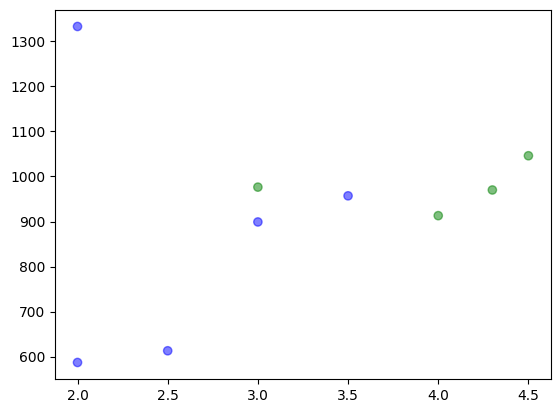

In [ ]:
plt.scatter(x, y, c=['g' if i == 'Costa Rica' else 'b' for i in z], marker='o', alpha=0.5)

<Axes: title={'center': 'cost'}, xlabel='[destination]'>

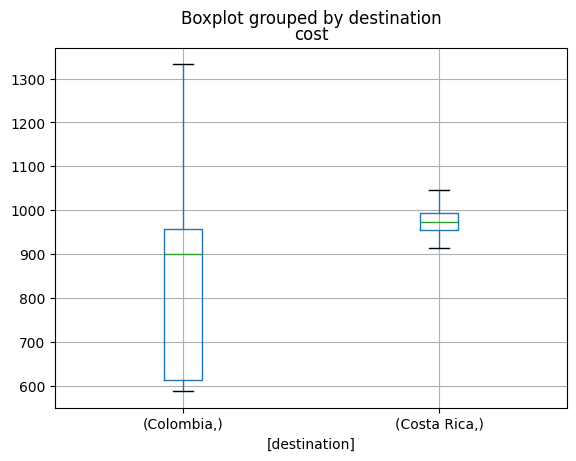

In [ ]:
data.boxplot(column=['cost'], by=['destination'])

In [ ]:
min_max_scaler = MinMaxScaler()

In [ ]:
min_max_scaler.fit(data[['cost']])

MinMaxScaler()

In [ ]:
data['cost_scaled'] = min_max_scaler.transform(data[['cost']])
data

,user_id,date_of_journey,duration,destination,cost,currency,age,name,cost_scaled
0,101,2018-01-16,3.0,Costa Rica,976.333333,USD,30.0,Tomas,0.521895
1,284,2017-07-13,3.0,Colombia,899.000000,USD,38.0,Jose,0.418231
2,136,2019-10-10,2.0,Colombia,587.000000,USD,38.0,Ana,0.000000
3,800,2018-03-20,4.0,Costa Rica,913.000000,USD,49.0,Carolina,0.436997
4,101,2019-12-24,2.0,Colombia,1333.000000,USD,30.0,Tomas,1.000000
5,800,2017-10-17,3.5,Colombia,957.000000,USD,49.0,Carolina,0.495979
6,823,2016-11-02,4.5,Costa Rica,1046.000000,USD,28.0,Katerine,0.615282
7,529,2019-09-14,2.5,Colombia,613.000000,USD,43.0,Viviana,0.034853
8,284,2019-08-07,4.3,Costa Rica,970.000000,USD,38.0,Jose,0.513405


In [ ]:
data['detination_encoded'] = (data['destination'] == 'Colombia').astype(int)
data

,user_id,date_of_journey,duration,destination,cost,currency,age,name,cost_scaled,detination_encoded
0,101,2018-01-16,3.0,Costa Rica,976.333333,USD,30.0,Tomas,0.521895,0
1,284,2017-07-13,3.0,Colombia,899.000000,USD,38.0,Jose,0.418231,1
2,136,2019-10-10,2.0,Colombia,587.000000,USD,38.0,Ana,0.000000,1
3,800,2018-03-20,4.0,Costa Rica,913.000000,USD,49.0,Carolina,0.436997,0
4,101,2019-12-24,2.0,Colombia,1333.000000,USD,30.0,Tomas,1.000000,1
5,800,2017-10-17,3.5,Colombia,957.000000,USD,49.0,Carolina,0.495979,1
6,823,2016-11-02,4.5,Costa Rica,1046.000000,USD,28.0,Katerine,0.615282,0
7,529,2019-09-14,2.5,Colombia,613.000000,USD,43.0,Viviana,0.034853,1
8,284,2019-08-07,4.3,Costa Rica,970.000000,USD,38.0,Jose,0.513405,0


In [ ]:
data['detination_encoded'] = data['destination'].map({'Costa Rica': 0, 'Colombia': 1})
data

,user_id,date_of_journey,duration,destination,cost,currency,age,name,cost_scaled,detination_encoded
0,101,2018-01-16,3.0,Costa Rica,976.333333,USD,30.0,Tomas,0.521895,0
1,284,2017-07-13,3.0,Colombia,899.000000,USD,38.0,Jose,0.418231,1
2,136,2019-10-10,2.0,Colombia,587.000000,USD,38.0,Ana,0.000000,1
3,800,2018-03-20,4.0,Costa Rica,913.000000,USD,49.0,Carolina,0.436997,0
4,101,2019-12-24,2.0,Colombia,1333.000000,USD,30.0,Tomas,1.000000,1
5,800,2017-10-17,3.5,Colombia,957.000000,USD,49.0,Carolina,0.495979,1
6,823,2016-11-02,4.5,Costa Rica,1046.000000,USD,28.0,Katerine,0.615282,0
7,529,2019-09-14,2.5,Colombia,613.000000,USD,43.0,Viviana,0.034853,1
8,284,2019-08-07,4.3,Costa Rica,970.000000,USD,38.0,Jose,0.513405,0


# House Prices Dataset

In [ ]:
!wget https://raw.githubusercontent.com/nicolasggiraldo/especializacion-udem-2025-02/refs/heads/main/data/house_prices_dataset/data_description.txt
!wget https://raw.githubusercontent.com/nicolasggiraldo/especializacion-udem-2025-02/refs/heads/main/data/house_prices_dataset/train.csv
!wget !wget https://raw.githubusercontent.com/nicolasggiraldo/especializacion-udem-2025-02/refs/heads/main/data/house_prices_dataset/test.csv
!mkdir -p house_price_data
!mv *.csv house_price_data/
!mv data_description.txt house_price_data/

--2026-05-03 18:13:41--  https://raw.githubusercontent.com/nicolasggiraldo/especializacion-udem-2025-02/refs/heads/main/data/house_prices_dataset/data_description.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13370 (13K) [text/plain]
Saving to: ‘data_description.txt’

data_description.tx 100%[===================>]  13.06K  --.-KB/s    in 0s      

2026-05-03 18:13:42 (85.3 MB/s) - ‘data_description.txt’ saved [13370/13370]

--2026-05-03 18:13:42--  https://raw.githubusercontent.com/nicolasggiraldo/especializacion-udem-2025-02/refs/heads/main/data/house_prices_dataset/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubuserc

In [ ]:
!cat house_price_data/data_description.txt

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [ ]:
df = pd.read_csv('house_price_data/train.csv')
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
na_count = df.isna().sum()
na_count[na_count > 0]

,0
LotFrontage,259
Alley,1369
MasVnrType,872
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


In [ ]:
df['LotFrontage'].min()

21.0

Teniendo en cuenta que no hay valores cero en `LotFrontage` podemos asumir que los valores nulos significan que no hay conexion con la calle



In [ ]:
df['LotFrontage'] = df['LotFrontage'].fillna(0)

In [ ]:
df['Alley'].unique()

array([nan, 'Grvl', 'Pave'], dtype=object)

In [ ]:
df['Alley'] = df['Alley'].fillna('No Alley')

In [ ]:
df[df["MasVnrArea"].isna()]['MasVnrType']

,MasVnrType
234,NaN
529,NaN
650,NaN
936,NaN
973,NaN
977,NaN
1243,NaN
1278,NaN


In [ ]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

In [ ]:
df[(df["MasVnrType"].isna()) & (df["MasVnrArea"] != 0)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
624,625,60,RL,80.0,10400,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,165150
773,774,20,RL,70.0,10150,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2007,COD,Normal,114500
1230,1231,90,RL,0.0,18890,Pave,No Alley,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,8300,8,2007,WD,Normal,190000
1300,1301,60,RL,0.0,10762,Pave,No Alley,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,225000
1334,1335,160,RM,24.0,2368,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,125000


In [ ]:
df = df[~((df["MasVnrType"].isna()) & (df["MasVnrArea"] != 0))].reset_index(drop=True)

In [ ]:
df['MasVnrType'] = df['MasVnrType'].fillna('None')

In [ ]:
df[df['BsmtQual'].isna()]['BsmtCond'].unique()

array([nan], dtype=object)

In [ ]:
df[df['BsmtCond'].isna()]['BsmtQual'].unique()

array([nan], dtype=object)

In [ ]:
df['BsmtQual'] = df['BsmtQual'].fillna('No Basement')
df['BsmtCond'] = df['BsmtCond'].fillna('No Basement')

In [ ]:
colnames = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
cond = (df['BsmtQual'].isna()) & (df['BsmtCond'].isna()) & (df['BsmtExposure'].isna()) & (df['BsmtFinType1'].isna()) & (df['BsmtFinType2'].isna())
for col in colnames:
  df.loc[cond, col] = 'No Basement'

In [ ]:
nan_rows = df[df[colnames].isnull().any(axis=1)]
print(nan_rows.shape)
nan_rows.head()

(39, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
17,18,90,RL,72.0,10791,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
39,40,90,RL,65.0,6040,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,AdjLand,82000
90,91,20,RL,60.0,7200,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,109900
102,103,90,RL,64.0,7018,Pave,No Alley,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Alloca,118964
156,157,20,RL,60.0,7200,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,109500


In [ ]:
df = df.dropna(subset=colnames)
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,No Alley,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,No Alley,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,No Alley,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1450,1456,60,RL,62.0,7917,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1451,1457,20,RL,85.0,13175,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1452,1458,70,RL,66.0,9042,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1453,1459,20,RL,68.0,9717,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
df['Electrical'].unique()

array(['SBrkr', 'FuseF', 'FuseA', 'FuseP', 'Mix', nan], dtype=object)

In [ ]:
df[df['Electrical'].isna()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1374,1380,80,RL,73.0,9735,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500


In [ ]:
df = df.dropna(subset=['Electrical'])

In [ ]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,No Alley,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,No Alley,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,No Alley,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1450,1456,60,RL,62.0,7917,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1451,1457,20,RL,85.0,13175,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1452,1458,70,RL,66.0,9042,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1453,1459,20,RL,68.0,9717,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
df[df['FireplaceQu'].isna()]['Fireplaces'].unique()

array([0])

In [ ]:
df[df['Fireplaces'] == 0]['FireplaceQu'].unique()

array([nan], dtype=object)

In [ ]:
df['FireplaceQu'] = df['FireplaceQu'].fillna('No Fireplace')

/tmp/ipykernel_15172/2809107247.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FireplaceQu'] = df['FireplaceQu'].fillna('No Fireplace')


In [ ]:
colnames = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
for col in colnames:
  df[col] = df[col].fillna('No Garage')

/tmp/ipykernel_15172/3129217013.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna('No Garage')


In [ ]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(-1).astype(int)

/tmp/ipykernel_15172/1715235029.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['GarageYrBlt'] = df['GarageYrBlt'].fillna(-1).astype(int)


In [ ]:
df[df['PoolQC'].isna()]['PoolArea'].unique()

array([0])

In [ ]:
df['PoolQC'] = df['PoolQC'].fillna('No Pool')

/tmp/ipykernel_15172/1552120304.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PoolQC'] = df['PoolQC'].fillna('No Pool')


In [ ]:
df['Fence'] = df['Fence'].fillna('No Fence')

/tmp/ipykernel_15172/477322962.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fence'] = df['Fence'].fillna('No Fence')


In [ ]:
df[df['MiscFeature'].isna()]['MiscVal'].unique()

array([0])

In [ ]:
df['MiscFeature'] = df['MiscFeature'].fillna('None')

/tmp/ipykernel_15172/2522058577.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MiscFeature'] = df['MiscFeature'].fillna('None')


In [ ]:
na_count = df.isna().sum()
na_count[na_count > 0]

,0


# Transformacion de datos

In [ ]:
dtypes = df.dtypes.reset_index()
dtypes.columns = ['column_name', 'dtype']
dtypes

,column_name,dtype
0,Id,int64
1,MSSubClass,int64
2,MSZoning,object
3,LotFrontage,float64
4,LotArea,int64
...,...,...
76,MoSold,int64
77,YrSold,int64
78,SaleType,object
79,SaleCondition,object


In [ ]:
categoric_columns = [row['column_name'] for _, row in dtypes.iterrows() if row['dtype'] == 'object']
for col in categoric_columns:
  print(df[col].value_counts() / df.shape[0])

MSZoning
RL         0.785866
RM         0.150530
FV         0.045936
RH         0.010601
C (all)    0.007067
Name: count, dtype: float64
Street
Pave    0.99576
Grvl    0.00424
Name: count, dtype: float64
Alley
No Alley    0.936396
Grvl        0.034629
Pave        0.028975
Name: count, dtype: float64
LotShape
Reg    0.628269
IR1    0.336396
IR2    0.028269
IR3    0.007067
Name: count, dtype: float64
LandContour
Lvl    0.897527
Bnk    0.043110
HLS    0.035336
Low    0.024028
Name: count, dtype: float64
Utilities
AllPub    0.999293
NoSeWa    0.000707
Name: count, dtype: float64
LotConfig
Inside     0.718728
Corner     0.181625
CulDSac    0.064311
FR2        0.032509
FR3        0.002827
Name: count, dtype: float64
LandSlope
Gtl    0.945583
Mod    0.045230
Sev    0.009187
Name: count, dtype: float64
Neighborhood
NAmes      0.151237
CollgCr    0.105300
OldTown    0.078445
Edwards    0.062898
Somerst    0.060777
Gilbert    0.054417
NridgHt    0.053710
NWAmes     0.050883
Sawyer     0.050177
B

In [ ]:
df[categoric_columns]

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,No Alley,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,No Pool,No Fence,None,WD,Normal
1,RL,Pave,No Alley,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,No Pool,No Fence,None,WD,Normal
2,RL,Pave,No Alley,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,No Pool,No Fence,None,WD,Normal
3,RL,Pave,No Alley,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,No Pool,No Fence,None,WD,Abnorml
4,RL,Pave,No Alley,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,No Pool,No Fence,None,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1450,RL,Pave,No Alley,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,Attchd,RFn,TA,TA,Y,No Pool,No Fence,None,WD,Normal
1451,RL,Pave,No Alley,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,Attchd,Unf,TA,TA,Y,No Pool,MnPrv,None,WD,Normal
1452,RL,Pave,No Alley,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,...,Attchd,RFn,TA,TA,Y,No Pool,GdPrv,Shed,WD,Normal
1453,RL,Pave,No Alley,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,No Pool,No Fence,None,WD,Normal


Trabajemos con las siguientes columnas

In [ ]:
features= [
    "Id", "LotArea", "Neighborhood", "BldgType", "HouseStyle", "OverallQual",
    "OverallCond", "YearBuilt", "YearRemodAdd", "RoofStyle", "RoofMatl", "GrLivArea",
    "FullBath", "HalfBath", "BedroomAbvGr", "KitchenAbvGr", "MoSold", "YrSold", "SalePrice"
]
numfeat= [
    "Id", "LotArea", "OverallQual",
    "OverallCond", "YearBuilt", "YearRemodAdd", "GrLivArea",
    "FullBath", "HalfBath", "BedroomAbvGr", "KitchenAbvGr", "MoSold", "YrSold", "SalePrice"
]
catfeat= ["Id", "Neighborhood", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl"]

In [ ]:
house_data = df.loc[:, features].reset_index(drop=True)

In [ ]:
ohe = OneHotEncoder(categories='auto')

feature_arr = ohe.fit_transform(house_data[catfeat[1:]]).toarray()

ohe_labels = ohe.get_feature_names_out(catfeat[1:])

encoder_features = pd.DataFrame(feature_arr, columns=ohe_labels)
encoder_features

,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,...,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1410,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1411,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1412,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1413,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


# Analisis exploratorio

In [ ]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1415 entries, 0 to 1414
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Id            1415 non-null   int64 
 1   LotArea       1415 non-null   int64 
 2   Neighborhood  1415 non-null   object
 3   BldgType      1415 non-null   object
 4   HouseStyle    1415 non-null   object
 5   OverallQual   1415 non-null   int64 
 6   OverallCond   1415 non-null   int64 
 7   YearBuilt     1415 non-null   int64 
 8   YearRemodAdd  1415 non-null   int64 
 9   RoofStyle     1415 non-null   object
 10  RoofMatl      1415 non-null   object
 11  GrLivArea     1415 non-null   int64 
 12  FullBath      1415 non-null   int64 
 13  HalfBath      1415 non-null   int64 
 14  BedroomAbvGr  1415 non-null   int64 
 15  KitchenAbvGr  1415 non-null   int64 
 16  MoSold        1415 non-null   int64 
 17  YrSold        1415 non-null   int64 
 18  SalePrice     1415 non-null   int64 
dtypes: int

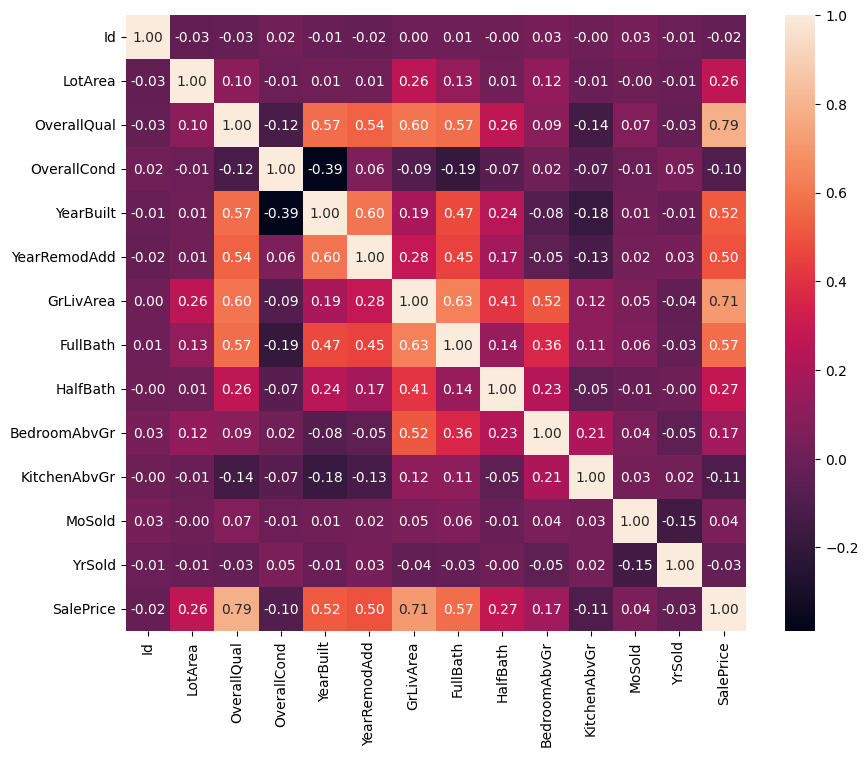

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(house_data[numfeat].corr(), annot=True, fmt='.2f');

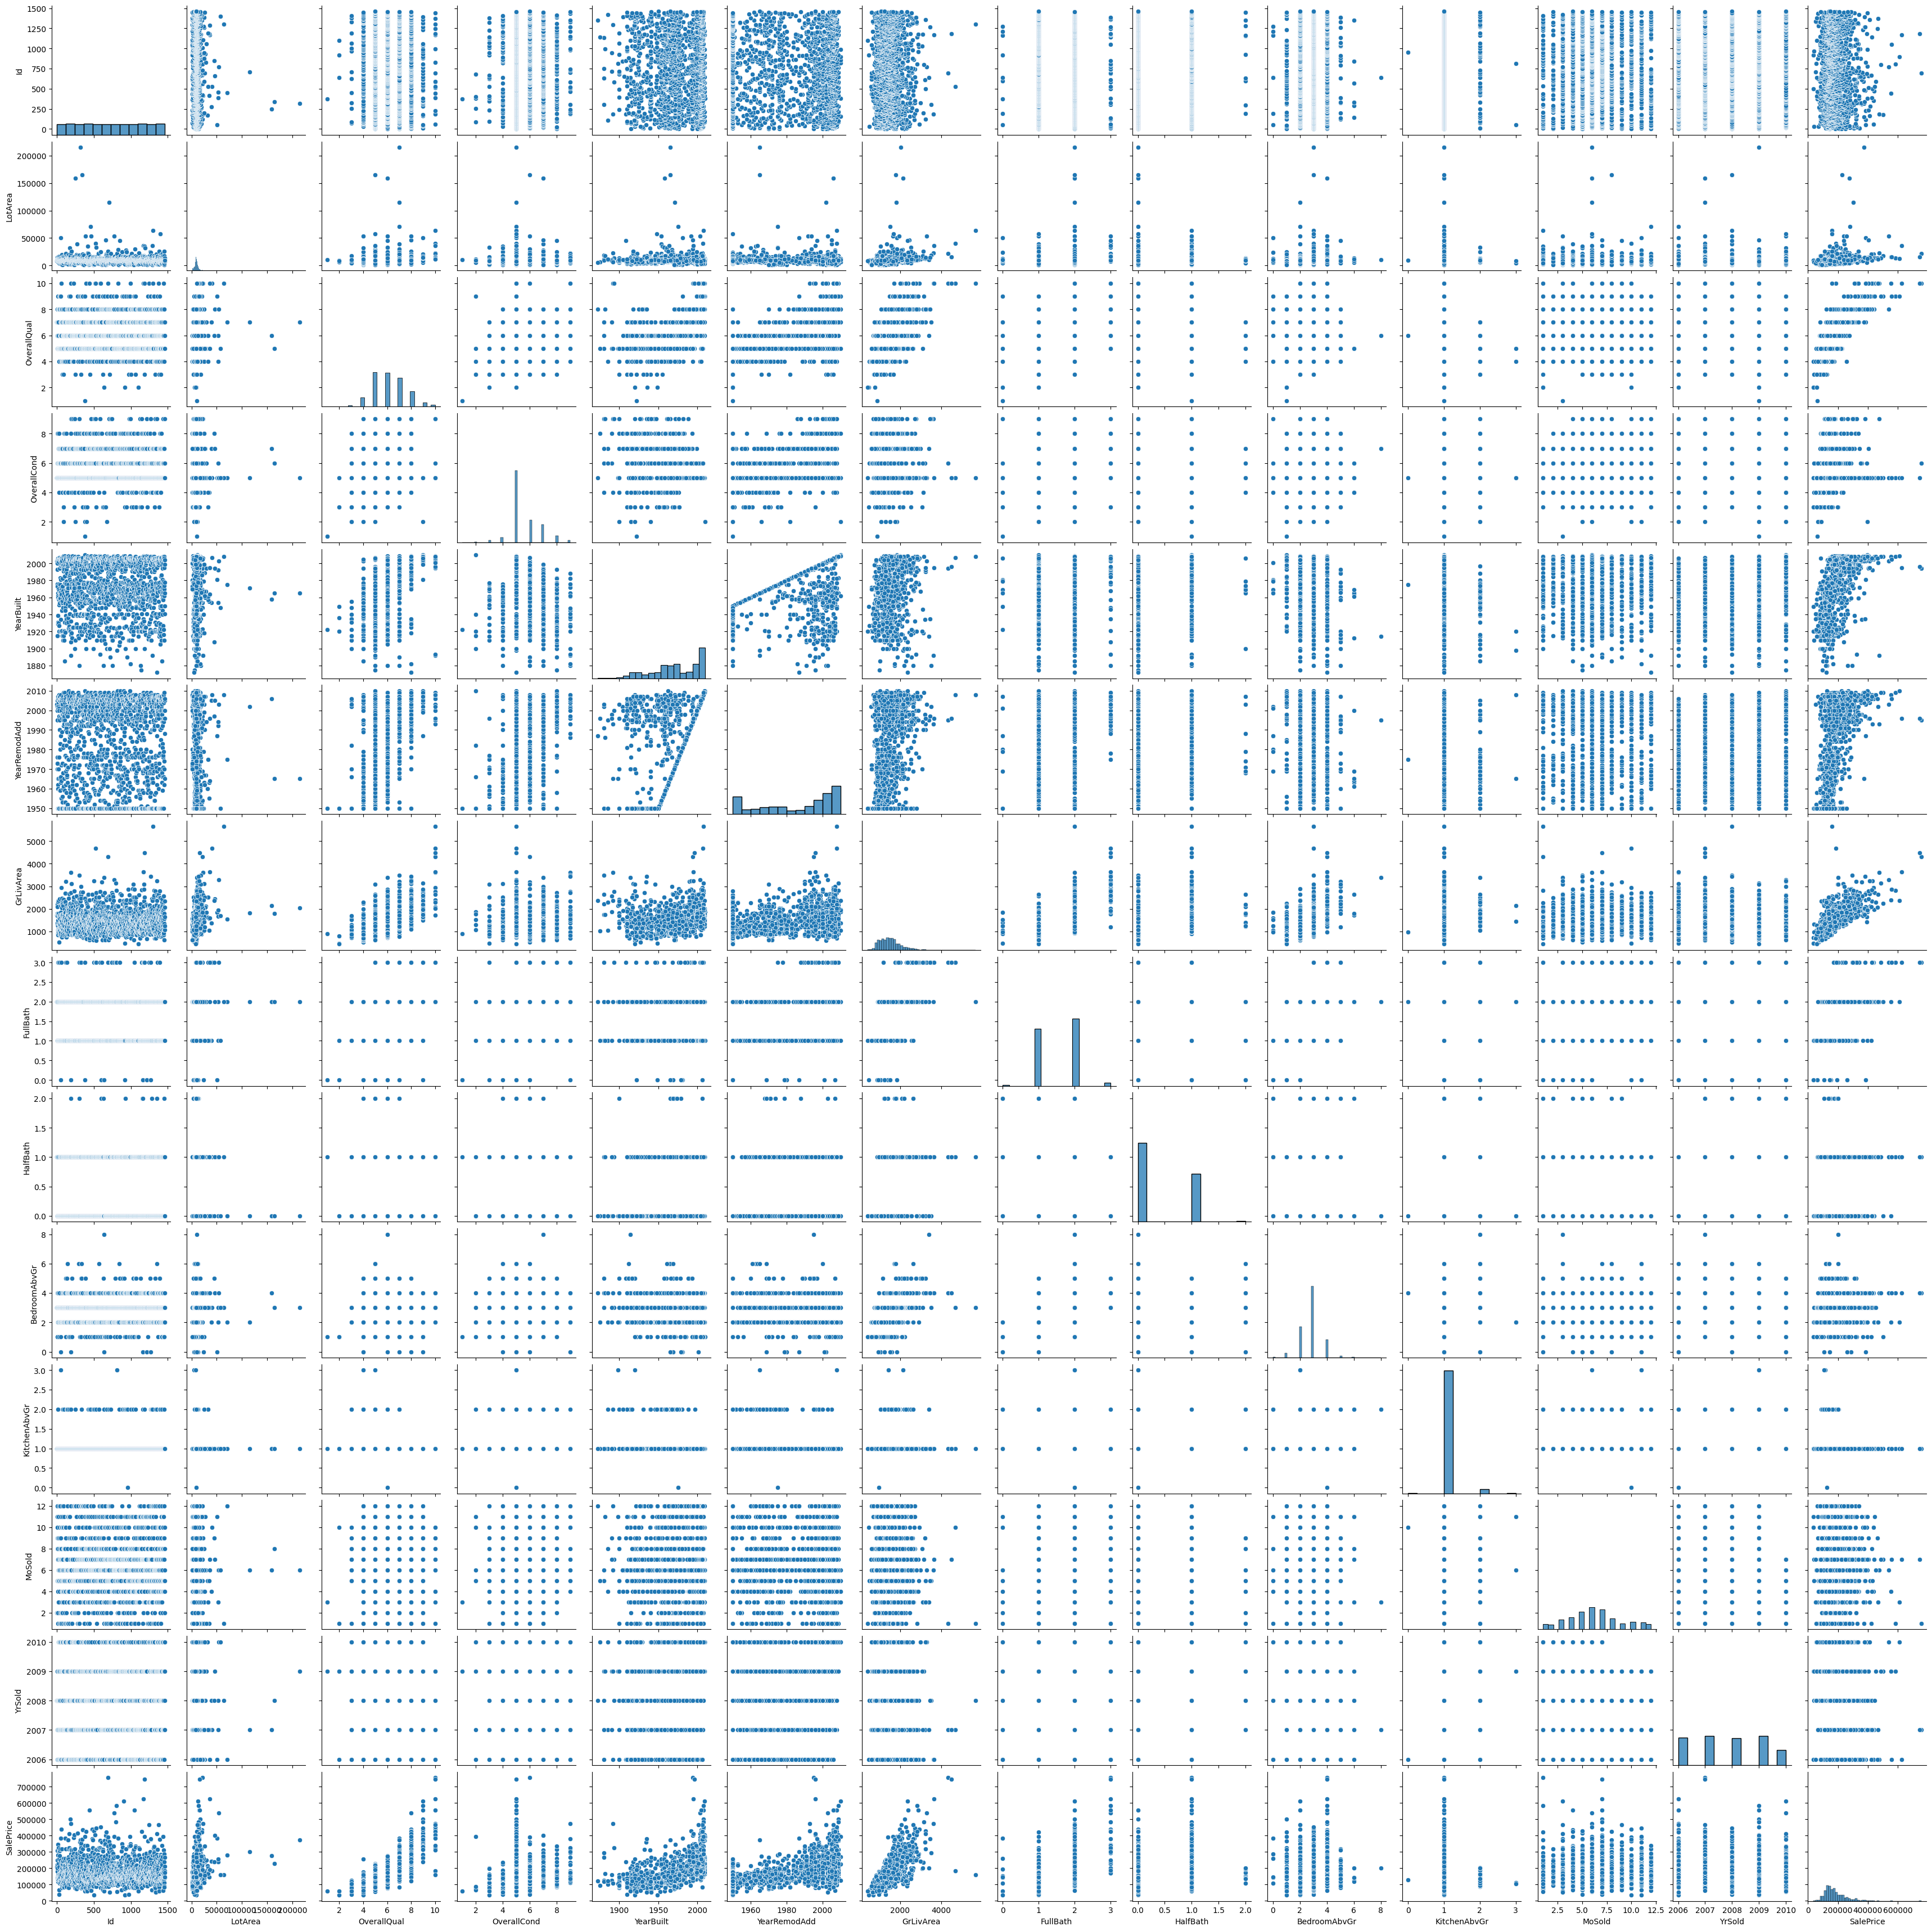

In [ ]:
sns.pairplot(house_data);

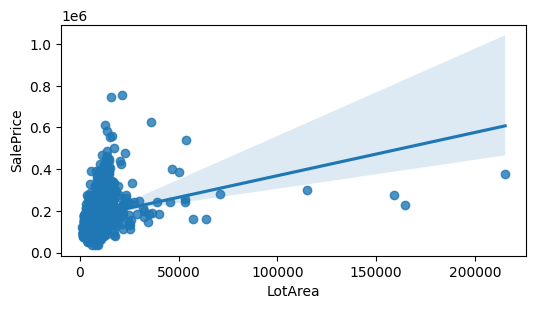

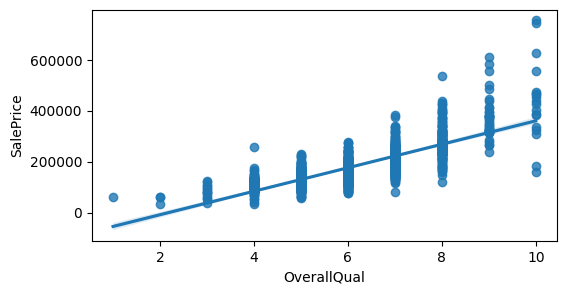

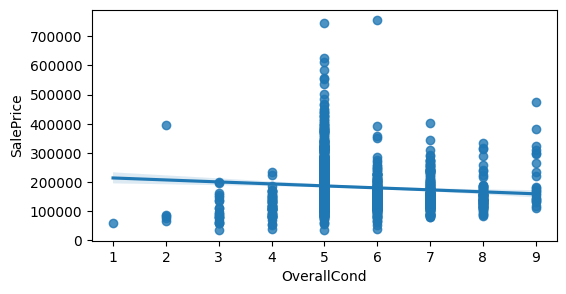

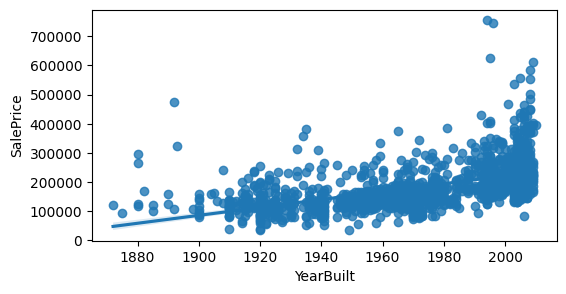

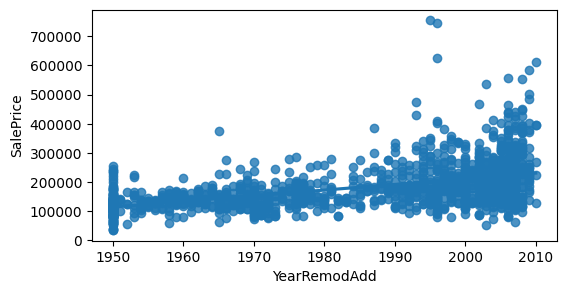

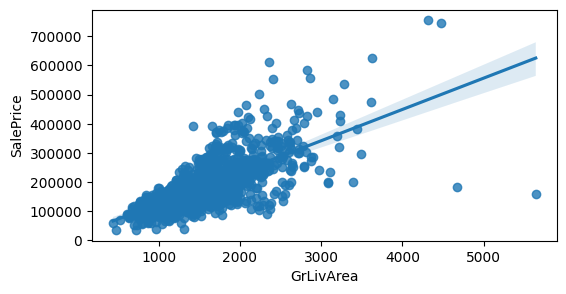

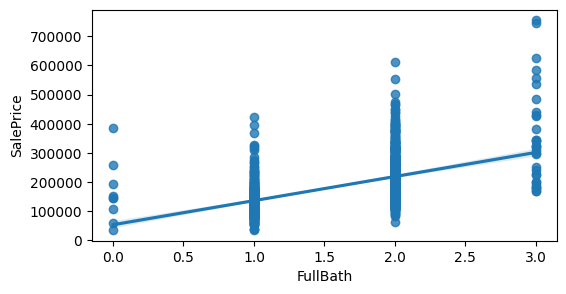

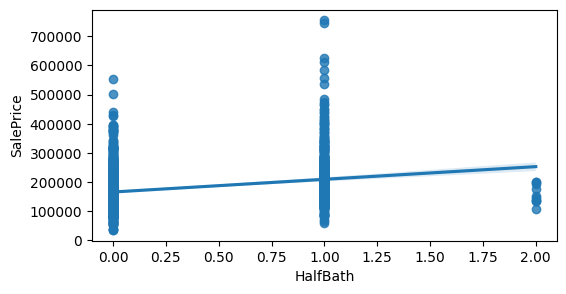

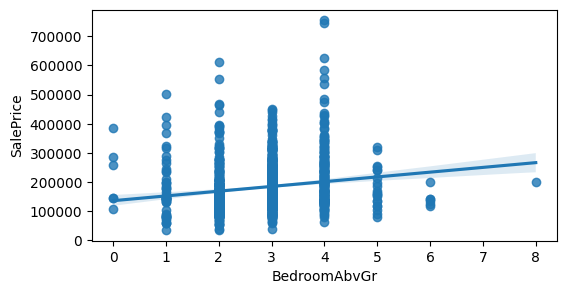

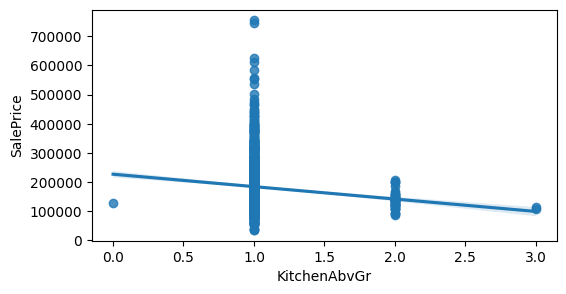

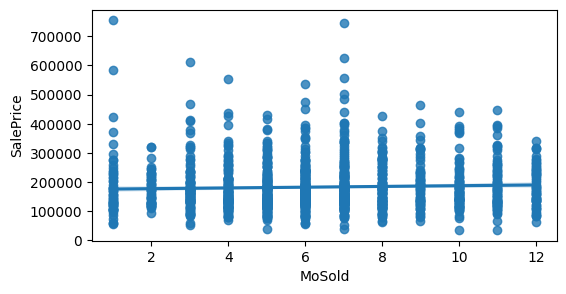

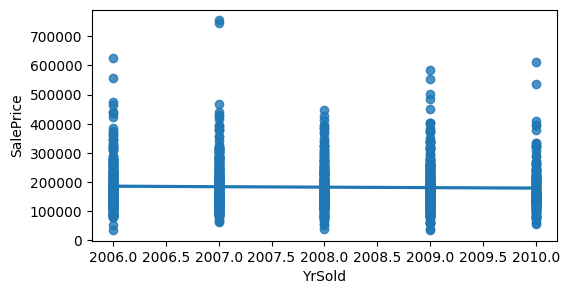

In [ ]:
for f in numfeat[1:-1]:
    #ax = plt.gca()
    ax=plt.subplots(figsize=(6,3))
    ax=sns.regplot(x=house_data[f], y=house_data['SalePrice'])
    plt.show()

Text(0.5, 1.0, 'Salesprice Boxplot')

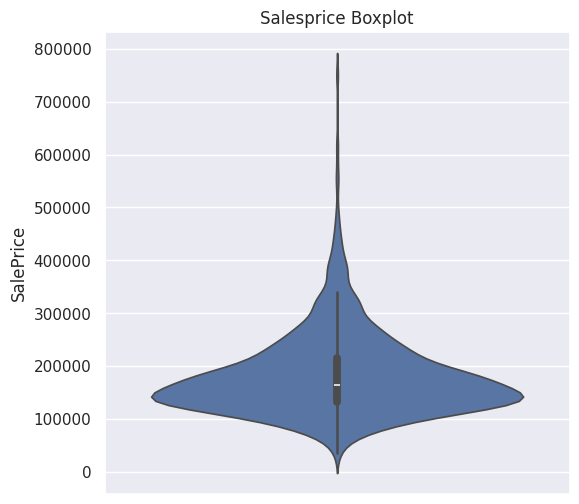

In [ ]:
plt.figure(figsize=(6,6))
sns.set_theme(color_codes=True)
sns.violinplot(data=house_data, y="SalePrice")
plt.title('Salesprice Boxplot')

Neighborhood


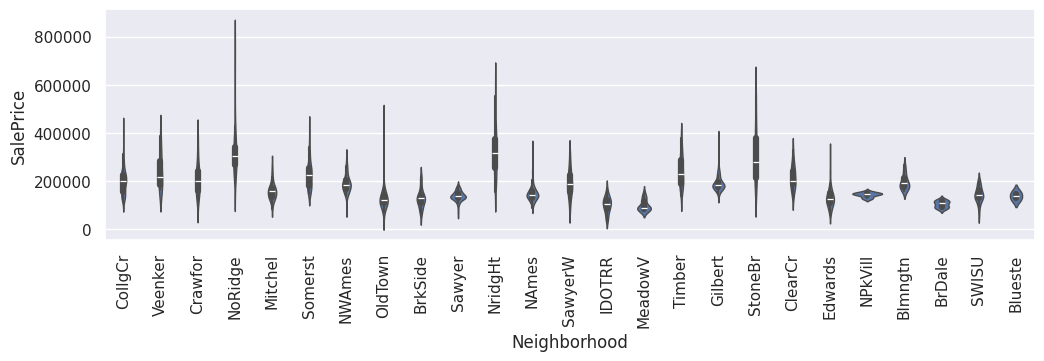

BldgType


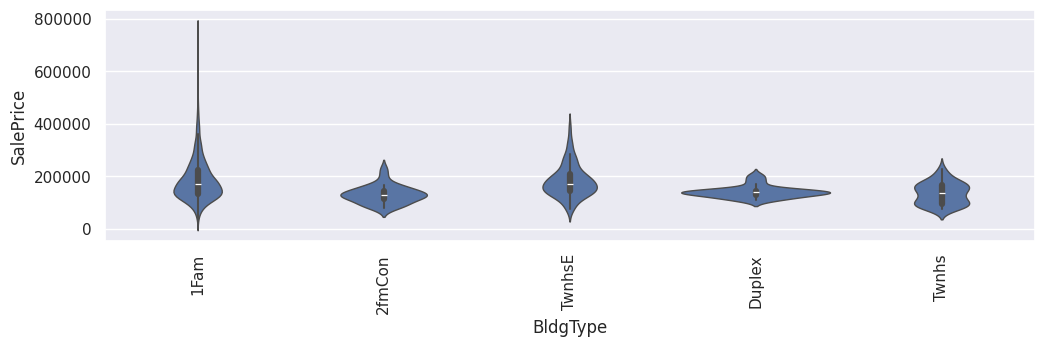

HouseStyle


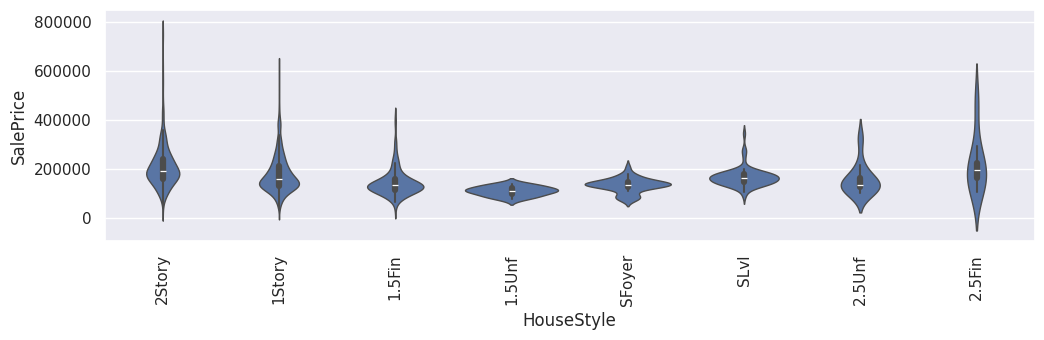

RoofStyle


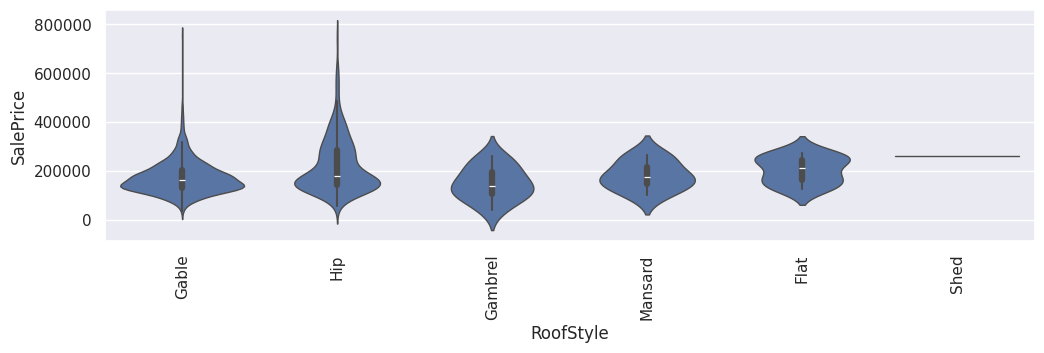

RoofMatl


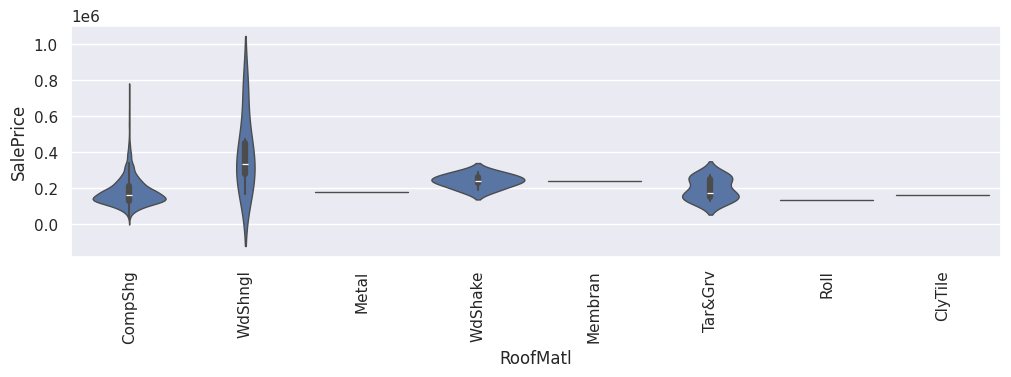

In [ ]:
for n in catfeat[1:]:
    print(n)
    ax = plt.subplots(figsize=(12, 3))
    plt.xticks(rotation='vertical')
    ax=sns.violinplot(x=n, y="SalePrice", data=house_data, linewidth=1)
    plt.show()

## que tan tan antiguas con las casas?

<Axes: >

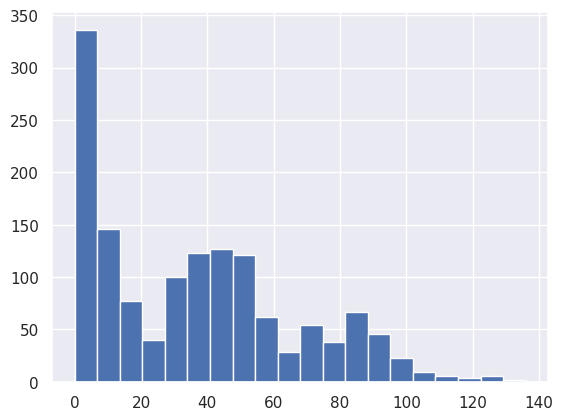

In [ ]:
house_data["HouseAge"] = house_data["YrSold"] - house_data["YearBuilt"]
house_data["HouseAge"].hist(bins=20)

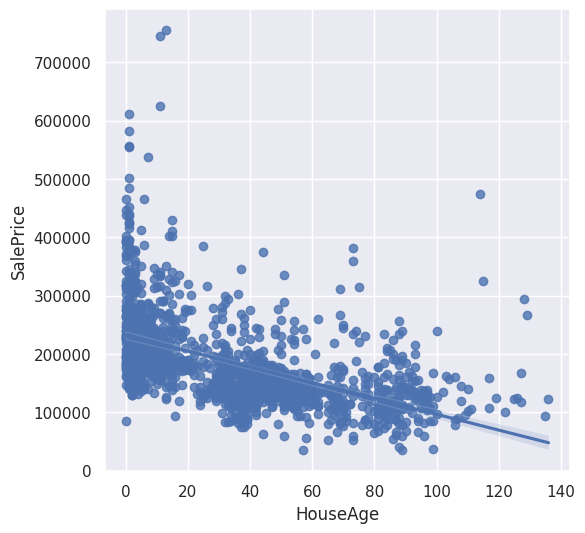

In [ ]:
plt.figure(figsize=(6,6))
sns.set_theme(color_codes=True)
ax = sns.regplot(data=house_data, x="HouseAge", y="SalePrice")

In [ ]:
house_data

,Id,LotArea,Neighborhood,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,GrLivArea,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,MoSold,YrSold,SalePrice,HouseAge
0,1,8450,CollgCr,1Fam,2Story,7,5,2003,2003,Gable,CompShg,1710,2,1,3,1,2,2008,208500,5
1,2,9600,Veenker,1Fam,1Story,6,8,1976,1976,Gable,CompShg,1262,2,0,3,1,5,2007,181500,31
2,3,11250,CollgCr,1Fam,2Story,7,5,2001,2002,Gable,CompShg,1786,2,1,3,1,9,2008,223500,7
3,4,9550,Crawfor,1Fam,2Story,7,5,1915,1970,Gable,CompShg,1717,1,0,3,1,2,2006,140000,91
4,5,14260,NoRidge,1Fam,2Story,8,5,2000,2000,Gable,CompShg,2198,2,1,4,1,12,2008,250000,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1410,1456,7917,Gilbert,1Fam,2Story,6,5,1999,2000,Gable,CompShg,1647,2,1,3,1,8,2007,175000,8
1411,1457,13175,NWAmes,1Fam,1Story,6,6,1978,1988,Gable,CompShg,2073,2,0,3,1,2,2010,210000,32
1412,1458,9042,Crawfor,1Fam,2Story,7,9,1941,2006,Gable,CompShg,2340,2,0,4,1,5,2010,266500,69
1413,1459,9717,NAmes,1Fam,1Story,5,6,1950,1996,Hip,CompShg,1078,1,0,2,1,4,2010,142125,60


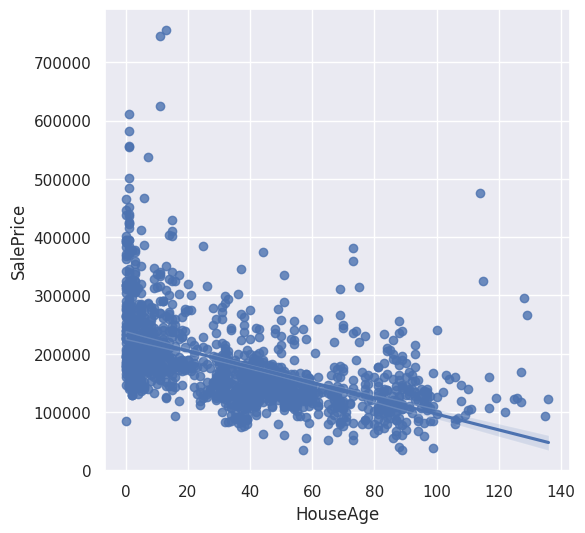

In [ ]:
plt.figure(figsize=(6,6))
sns.set_theme(color_codes=True)
ax = sns.regplot(data=house_data, x="HouseAge", y="SalePrice")

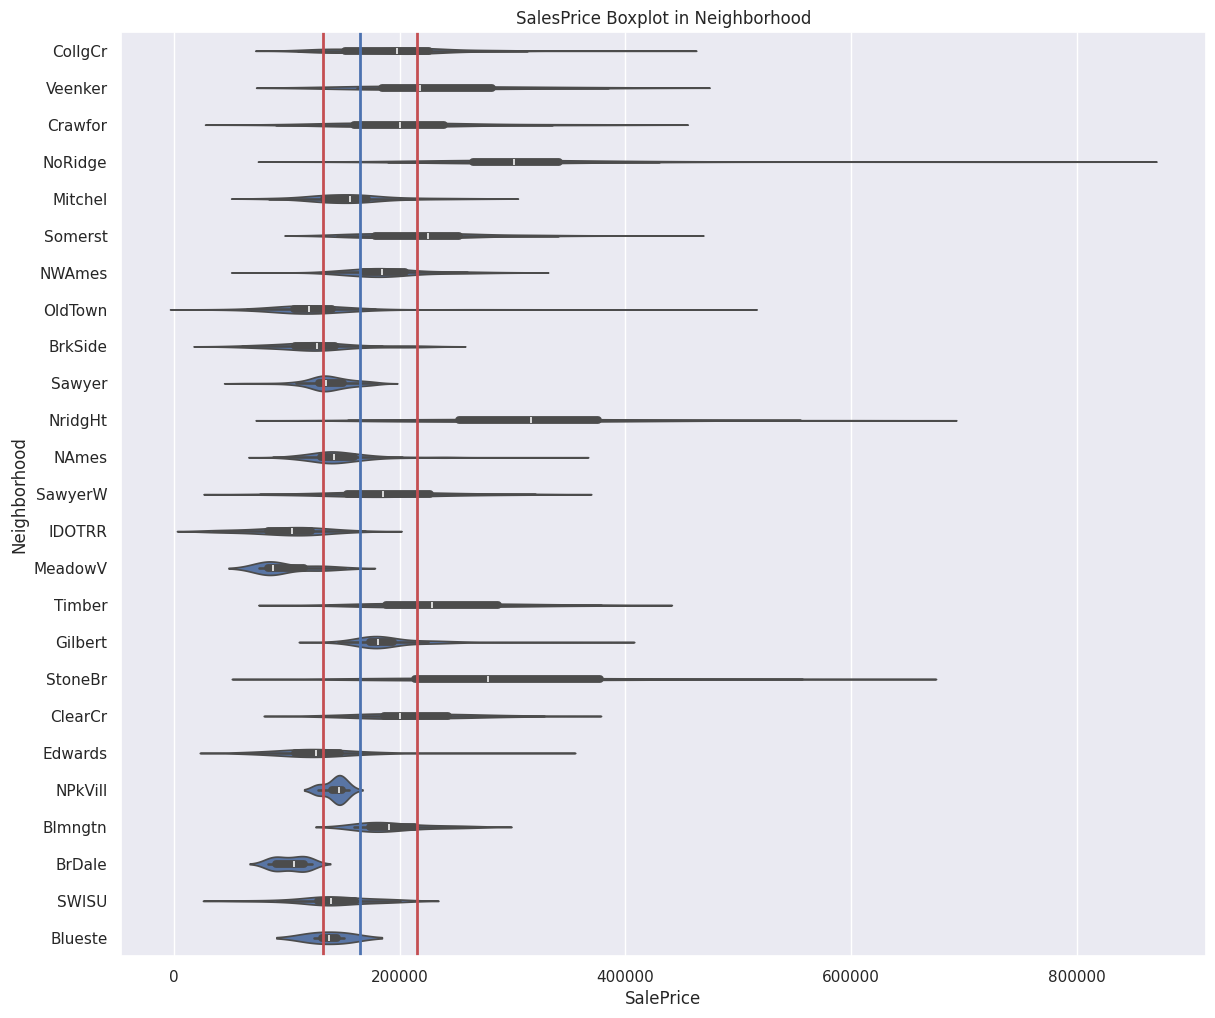

In [ ]:
plt.figure(figsize=(14,12))
sns.violinplot(data=house_data, x="SalePrice", y="Neighborhood", orient = 'h')
plt.title('SalesPrice Boxplot in Neighborhood')
plt.ylabel('Neighborhood')

plt.axvline(x=np.percentile(house_data['SalePrice'], q=25), linewidth=2, color='r')
plt.axvline(x=np.percentile(house_data['SalePrice'], q=50), linewidth=2, color='b')
plt.axvline(x=np.percentile(house_data['SalePrice'], q=75), linewidth=2, color='r');

In [ ]:
data = pd.concat([house_data, encoder_features], axis=1)

In [ ]:
X = data.drop(columns=catfeat + ['SalePrice'])
y = data['SalePrice']

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_valid, Y_train, Y_valid = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=0)

In [ ]:
from sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_percentage_error

model_SVR = svm.SVR()
model_SVR.fit(X_train,Y_train)
Y_pred = model_SVR.predict(X_valid)

print(mean_absolute_percentage_error(Y_valid, Y_pred))

0.30148158581090756


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_RFR = RandomForestRegressor(n_estimators=10)
model_RFR.fit(X_train, Y_train)
Y_pred = model_RFR.predict(X_valid)

mean_absolute_percentage_error(Y_valid, Y_pred)

0.11350770659100004

In [ ]:
from sklearn.linear_model import LinearRegression

model_LR = LinearRegression()
model_LR.fit(X_train, Y_train)
Y_pred = model_LR.predict(X_valid)

print(mean_absolute_percentage_error(Y_valid, Y_pred))

0.11991335292606953


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

model=XGBRegressor(n_estimators=2500,learning_rate=0.01,max_depth=8,subsample=0.8,n_jobs=8,random_state=42)

In [ ]:
model.fit(X_train, Y_train)
Y_pred= model.predict(X_valid)

print(mean_absolute_percentage_error(Y_valid, Y_pred))

0.11496731638908386


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from math import sqrt

In [ ]:
lr = LinearRegression()
lr.fit(X, y)

LinearRegression()

In [ ]:
y_pred = lr.predict(X)
r2 = r2_score(y, y_pred)

In [ ]:
r2

In [ ]:
lr.coef_

array([ 5.83301384e-01,  1.30916238e+04,  6.74915852e+03,  3.06885578e+02,
        8.51453696e+01,  8.70310510e+01, -3.78612508e+02,  2.18497925e+03,
       -8.74490501e+03, -1.92632361e+04, -6.49160283e+02,  4.45367317e+01,
       -2.62348846e+02, -6.05872920e+03,  7.07121073e+03,  1.25438184e+04,
       -3.39572658e+03, -1.30708830e+04, -1.08676797e+04,  1.01449821e+04,
       -1.67917433e+04, -1.82806165e+04, -1.33319201e+04,  8.75358141e+03,
       -1.52196243e+04, -1.67575587e+04,  1.72775151e+04, -2.77315139e+04,
        2.99286899e+04,  4.91047921e+04, -1.88756563e+04, -1.39400731e+04,
       -1.66196579e+04, -1.35123524e+04,  8.48592286e+03,  5.35915714e+04,
       -2.60587080e+03,  1.01575218e+04,  1.60391964e+04,  2.09537119e+04,
        1.26037273e+04, -3.27099529e+04, -1.68866827e+04, -3.30061232e+03,
        1.26539349e+04,  1.72839945e+04, -3.93480146e+04, -1.26825497e+04,
       -7.41052354e+03,  2.30084751e+04,  9.79529568e+03, -6.77526198e+03,
       -2.00091302e+04, -

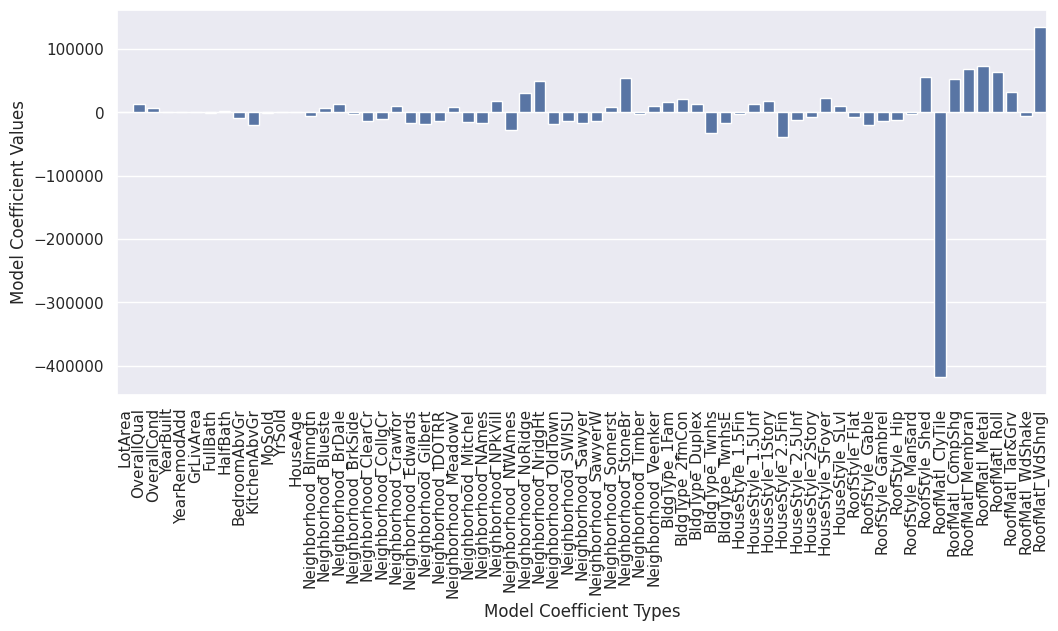

In [ ]:
plt.subplots(figsize=(12,5))
sns.barplot(x=0, y=1, data=pd.DataFrame(zip(X.columns, lr.coef_)))
plt.xticks(rotation='vertical')
plt.xlabel("Model Coefficient Types")
plt.ylabel("Model Coefficient Values")
plt.show();

R squared:  0.861902627666499
Average Coefficients: 25401.41834752588
Root Mean Squared Error: 29540.235274817092


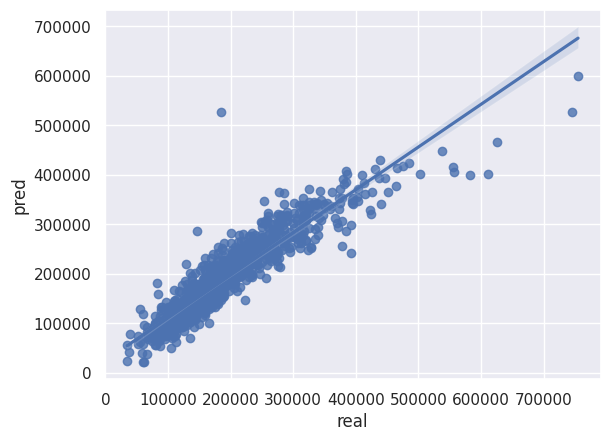

In [ ]:
print("R squared: ", (r2))
print("Average Coefficients:", (abs(lr.coef_).mean()))
print("Root Mean Squared Error:", sqrt(mean_squared_error(y, y_pred)))
sns.regplot(x=y, y=y_pred)
plt.xlabel('real')
plt.ylabel('pred');

In [ ]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(lr, X, y, n_jobs=1, cv=5))

np.float64(0.8148327585426669)